<a href="https://colab.research.google.com/github/vasanramani/aiaba-uta/blob/main/proj2-ai-agent-ehr/assignment-v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Initial Setup**

## Installing Libraries and Dependencies

In [1]:
!pip -q install \
  langgraph==0.2.39 \
  langchain==0.3.14 \
  langchain-core==0.3.29 \
  langchain-community==0.3.14 \
  langsmith==0.1.147 \
  openai==1.59.6 \
  langchain-openai==0.2.14 \
  pydantic==2.10.4 \
  pandas==2.2.3 \
  numpy==2.2.1

## Importing Necessary Libaries and Dependencies

In [2]:
import os              # environment variables / runtime config
import re              # text normalization + lightweight pattern matching
import json            # serialize/parse tool outputs + structured data interchange
import sqlite3         # connect/query the SQLite database
import pandas as pd    # load/query CSV reference data
import numpy as np     # numeric utilities
from typing import Any, Dict, List, Optional, TypedDict, Tuple  # type hints + structured state for agent workflow

from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage, ToolMessage  # chat + tool observation messages
from langchain_core.prompts import ChatPromptTemplate  # consistent prompt templates
from langchain_core.tools import tool                 # define LLM-callable tools
from langchain_core.output_parsers import JsonOutputParser  # parse LLM outputs into JSON

from langchain_openai import ChatOpenAI  # OpenAI chat model wrapper

from langgraph.graph import StateGraph, END  # build the LangGraph state machine + termination node

from IPython.display import Markdown, Image, display  # visualize the graph / notebook-friendly display

## Identify environment to switch from local to google drive

In [3]:
# Identify the environment to switch the file paths either to use Google Drive or Local
import sys
# Check if the operating system is Windows
if sys.platform.startswith('win'):
    print("Running on Windows")
    resourcePath=""
else:
    # Assume it's a Linux-based environment, likely Google Colab
    print("Running on Linux most likely Colab")
    # Mount Google Drive for Colab environments to access files
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    # Define the base path for resources in Google Drive
    resourcePath="/content/drive/MyDrive/ColabAssignments/ReActEHR/"

Running on Linux most likely Colab
Mounted at /content/drive


## Resources

In [4]:
DB_PATH = resourcePath + "datafiles/health_portal.db"    # path to the SQLite database file
TRUSTED_SOURCES_CSV = resourcePath + "datafiles/trusted_sources_catalog.csv"    # path to the trusted_sources_catalog.csv file
LAB_EXPLAIN_CSV =  resourcePath + "datafiles/patient_friendly_lab_explanations.csv"    # path to the patient_friendly_lab_explanations.csv file
MED_EDU_CSV =  resourcePath + "datafiles/medication_education.csv"    # path to the medication_education.csv file
POLICY_RULES_CSV =  resourcePath + "datafiles/safety_policy_rules.csv"    # path to the safety_policy_rules.csv file

## Generic Utilities

In [5]:
def printmd(s: str):
    """Helper function to print markdown-formatted text in Jupyter notebooks.

    Inputs:
        s (str): The markdown-formatted string to be displayed.
    """
    display(Markdown(s))

In [6]:
def normalizeText(s: str) -> str:
    """Normalize text for consistent llm searching and matching (remove mulitple whitespaces to single, trim and lowercase).

    Inputs:
        s (str): Any input text (will be cast to string).

    Output:
        str: Normalized text with:
            - leading/trailing whitespace removed
            - converted to lowercase
            - internal whitespace collapsed to single spaces
    """
    return re.sub(r"\s+", " ", str(s).strip().lower())  # strip leading/trailing whitespace, convert to lowercase, and collapse multiple internal whitespace to single spaces

In [7]:
def toJson(obj: Any) -> str:
    """Convert a Python object into a JSON string safely.

    Inputs: obj(Any): Any Python object (dict/list/str/etc.). If the object contains
        non-JSON-serializable values (e.g., datetime, numpy types), they are
        converted to strings via default=str.

    Output: str: JSON-formatted string (UTF-8 friendly, ensure_ascii=False).
    """
    return json.dumps(obj, ensure_ascii=False, default=str)  # return JSON string, converting non-serializable objects to strings and allowing UTF-8 characters

In [8]:
def readCSV(fileName: str) -> pd.DataFrame:
    """Reads a CSV file and returns a pandas DataFrame.

    Inputs:
        fileName (str): The path to the CSV file to be read.

    Output:
        pd.DataFrame: A DataFrame containing the contents of the CSV file.
        If an error occurs, returns an empty DataFrame.
    """
    try:
        df = pd.read_csv(fileName)
        printmd(f"Successfully read {fileName} with {len(df)} rows.")
        return df
    except Exception as e:
        printmd(f"Error reading {fileName}: {e}")
        return pd.DataFrame()  # return empty DataFrame on error to avoid crashes in downstream code

In [9]:
def getCappedLimit(limit: int) -> int:
    max_limit = 10
    return max(1, min(int(limit), max_limit)) # ensure limit is an integer between 1 and max_limit (inclusive)

## Read all the CSV Resources

In [10]:
trusted_sources_df = readCSV(TRUSTED_SOURCES_CSV)
lab_explain_df     = readCSV(LAB_EXPLAIN_CSV)
med_edu_df         = readCSV(MED_EDU_CSV)
policy_rules_df    = readCSV(POLICY_RULES_CSV)

Successfully read /content/drive/MyDrive/ColabAssignments/ReActEHR/datafiles/trusted_sources_catalog.csv with 20 rows.

Successfully read /content/drive/MyDrive/ColabAssignments/ReActEHR/datafiles/patient_friendly_lab_explanations.csv with 30 rows.

Successfully read /content/drive/MyDrive/ColabAssignments/ReActEHR/datafiles/medication_education.csv with 30 rows.

Successfully read /content/drive/MyDrive/ColabAssignments/ReActEHR/datafiles/safety_policy_rules.csv with 10 rows.

In [11]:
con = sqlite3.connect(DB_PATH)
con.row_factory = sqlite3.Row  # return query results as dictionaries (column names as keys)
cur = con.cursor()

# List tables
tables = cur.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name").fetchall()
print("Tables:", [t["name"] for t in tables])

# Check row counts
for t in ["patients","encounters","clinical_notes","labs","medications","allergies"]:
    c = cur.execute(f"SELECT COUNT(*) AS n FROM {t}").fetchone()["n"]
    printmd(f"{t:15s} {c}")

Tables: ['allergies', 'clinical_notes', 'encounters', 'labs', 'medications', 'patients']


patients        10

encounters      29

clinical_notes  43

labs            141

medications     56

allergies       15

## Database utility functions

In [12]:
def queryDBSafe(q: str, params: tuple = ()):
    """Execute a parameterized SQL query on the SQLite cursor and return rows as dictionaries.

    Inputs:
        q (str): SQL query string (use ? placeholders for parameters).
        params (tuple): Parameters to bind to the query placeholders.

    Output:
        List[Dict[str, Any]]: Query results where each row is converted to a dict
        (column_name -> value). Returns an empty list if no rows match.
    """
    rows = cur.execute(q, params).fetchall()  # execute the parameterized query and fetch all results
    return [dict(r) for r in rows]            # convert each row from sqlite3.Row to a regular dictionary (column names as keys)

## Model Setup and Initialization

In [13]:
# Load the credentials JSON file and extract values
file_name = resourcePath + 'config.json'
with open(file_name, 'r') as file:
    config = json.load(file)
    OPENAI_API_KEY = config.get("OPENAI_API_KEY")
    OPENAI_API_BASE = config.get("OPENAI_API_BASE")

# Store API credentials in environment variables
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY                       # Set API key as environment variable
os.environ["OPENAI_BASE_URL"] = OPENAI_API_BASE                     # Set API base URL as environment variable

# set up the generator llm
llmGenerator = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)     # complete the code to define the temperature for the LLM
# set up the validator llm
llmValidator = ChatOpenAI(model="gpt-4o", temperature=0)            # complete the code to define the temperature for the LLM

## Tools

### **`get_patient_profile`**

In [14]:
@tool("get_patient_profile")
def get_patient_profile(patient_id: str) -> str:
    """Retrieve the basic patient profile from the database.

    Args:
        patient_id (str): The unique identifier for the patient (e.g., "P001").

    Returns:
        str: A JSON string containing the patient's profile information, including:
            - patient_id
            - first_name
            - last_name
            - birth_year
            - sex_at_birth
            - preferred_language
            - health_literacy_level
            - timezone
            - created_at
        If the patient is not found, returns a JSON string with an error message.
    """
    rows = queryDBSafe("""
        SELECT patient_id, first_name, last_name, birth_year, sex_at_birth,
               preferred_language, health_literacy_level, timezone, created_at
        FROM patients
        WHERE patient_id = ?
    """, (patient_id))
    return toJson(rows[0] if rows else {"error": f"Patient {patient_id} not found"})

### **`list_patient_encounters`**

In [15]:
@tool("list_patient_encounters")
def list_patient_encounters(patient_id: str, limit: int = 5) -> str:
    """
    Fetch a patient's most recent encouters

    This tool is used to provide visit context for summarization and navigation-style answers.

    Args:
        patient_id (str): Unique patient identifier (e.g., "P003").
        limit (int, optional): Maximum number of encounters to return. For safety and
            consistency, this value can be capped (between 3-7). Defaults to 5.

    Returns:
        str: A JSON string containing a list of encounter objects, each including:
            - encounter_id
            - encounter_date
            - encounter_type
            - reason_for_visit
            - diagnosis_summary
            - provider_specialty
            - followup_instructions
            - care_team_contact
        Returns "[]" (JSON empty list) if no encounters are found.
    """

    rows = queryDBSafe("""
        SELECT encounter_id, encounter_date, encounter_type, reason_for_visit,
               diagnosis_summary, provider_specialty, followup_instructions, care_team_contact
        FROM encounters
        WHERE patient_id = ?
        ORDER BY encounter_date DESC
        LIMIT ?
    """, (patient_id, getCappedLimit(limit)))
    return toJson(rows)

### **`get_recent_clinical_note`**

In [16]:
@tool("get_recent_clinical_note")
def get_recent_clinical_note(patient_id: str, note_type: str = "visit_note") -> str:
    """
    Retrieve the most recent clinical note for a patient.

    This tool supports note summarization about the last visit by
    pulling the latest note text for a specified note category.

    Args:
        patient_id (str): Unique patient identifier (e.g., "P001").
        note_type (str, optional): Type of note to retrieve. Allowed values are:
            - "visit_note"
            - "discharge_summary"
            Any other value is defaulted to "visit_note".

    Returns:
        str: A JSON string containing a single note object with fields:
            - note_id
            - encounter_id
            - patient_id
            - note_type
            - note_text
            - created_at
            - author_role
        If no matching note exists, returns a JSON string like:
        {"error": "No <note_type> found for patient <patient_id>"}.
    """
    if note_type not in ("visit_note", "discharge_summary"):
        note_type = "visit_note"

    rows = queryDBSafe("""
        SELECT note_id, encounter_id, patient_id, note_type, note_text, created_at, author_role
        FROM clinical_notes
        WHERE patient_id = ? AND note_type = ?
        ORDER BY created_at DESC
        LIMIT 1
    """, (patient_id, note_type))
    return toJson(rows[0] if rows else {"error": f"No {note_type} found for patient {patient_id}"})

### **`get_clinical_notes_for_encounter`**

In [17]:
@tool("get_clinical_notes_for_encounter")
def get_clinical_notes_for_encounter(encounter_id: str) -> str:
    """
    Retrieve all clinical notes linked to a specific encounter from the SQLite `clinical_notes` table.

    This tool is useful when the agent first identifies the relevant encounter (e.g., the most recent
    visit from `list_patient_encounters`) and then needs to fetch all associated note types (visit note,
    discharge summary) for a complete, encounter-scoped summary.

    Args:
        encounter_id (str): Unique encounter identifier to fetch notes for.

    Returns:
        str: A JSON string containing a list of note objects. Each note includes:
            - note_id
            - encounter_id
            - patient_id
            - note_type
            - note_text
            - created_at
            - author_role
        Returns "[]" (JSON empty list) if no notes are found for the encounter.
    """
    rows = queryDBSafe("""
        SELECT note_id, encounter_id, patient_id, note_type, note_text, created_at, author_role
        FROM clinical_notes
        WHERE encounter_id = ?
        ORDER BY created_at ASC
    """, (encounter_id))
    return toJson(rows)

### **`get_labs`**

In [18]:
@tool("get_labs")
def get_labs(patient_id: str, test_name: Optional[str] = None, limit: int = 10) -> str:
    """
    Fetch recent laboratory results for a patient from the SQLite `labs` table.

    This tool supports lab-explanation use cases by retrieving the most recent lab records,
    optionally filtered to a specific lab test name (case-insensitive exact match).

    Args:
        patient_id (str): Unique patient identifier (e.g., "P001").
        test_name (Optional[str], optional): If provided, restricts results to rows where
            `test_name` matches (case-insensitive). If None, returns a mix of recent labs.
        limit (int, optional): Maximum number of rows to return. For safety and prompt
            size control, the value can be capped (between 7-10). Defaults to 10.

    Returns:
        str: A JSON string containing a list of lab result objects, each including:
            - lab_result_id
            - ordered_date
            - result_date
            - loinc_code
            - test_name
            - value_numeric
            - value_text
            - unit
            - ref_range_low
            - ref_range_high
            - flag
            - lab_source
        Returns "[]" (JSON empty list) if no results are found.
    """
    limit = getCappedLimit(limit)  # ensure limit is within safe bounds
    if test_name:
        rows = queryDBSafe("""
            SELECT lab_result_id, ordered_date, result_date, loinc_code, test_name,
                   value_numeric, value_text, unit, ref_range_low, ref_range_high, flag, lab_source
            FROM labs
            WHERE patient_id = ? AND lower(test_name) = lower(?)
            ORDER BY result_date DESC
            LIMIT ?
        """, (patient_id, test_name, limit))
    else:
        rows = queryDBSafe("""
            SELECT lab_result_id, ordered_date, result_date, loinc_code, test_name,
                   value_numeric, value_text, unit, ref_range_low, ref_range_high, flag, lab_source
            FROM labs
            WHERE patient_id = ?
            ORDER BY result_date DESC
            LIMIT ?
        """, (patient_id, limit))

    return toJson(rows)

### **`get_medications`**

In [19]:
@tool("get_medications")
def get_medications(patient_id: str, status: str = "active") -> str:
    """
    Retrieve a patient's medication list from the SQLite `medications` table.

    This tool supports medication education and reconciliation-style questions by returning
    the patient's recorded medications along with basic directions (dose/route/frequency),
    status (active/stopped), and a high-level indication when available.

    Args:
        patient_id (str): Unique patient identifier (e.g., "P002").
        status (str, optional): Filter for medication status:
            - "active": only active meds
            - "stopped": only stopped meds
            - "all": both active and stopped
            Any other value defaults to "active".

    Returns:
        str: A JSON string containing a list of medication objects, each including:
            - med_id
            - rxnorm_code
            - med_name
            - dose
            - route
            - frequency
            - start_date
            - end_date
            - status
            - indication
            - prescriber_specialty
        Returns "[]" (JSON empty list) if no medications match the filter.
    """
    if status not in ("active", "stopped", "all"):
        status = "active"

    if status == "all":
        rows = queryDBSafe("""
            SELECT med_id, rxnorm_code, med_name, dose, route, frequency,
                   start_date, end_date, status, indication, prescriber_specialty
            FROM medications
            WHERE patient_id = ?
            ORDER BY status DESC, start_date DESC
        """, (patient_id,))
    else:
        rows = queryDBSafe("""
            SELECT med_id, rxnorm_code, med_name, dose, route, frequency,
                   start_date, end_date, status, indication, prescriber_specialty
            FROM medications
            WHERE patient_id = ? AND status = ?
            ORDER BY start_date DESC
        """, (patient_id, status))

    return toJson(rows)

### **`get_allergies`**

In [20]:
@tool("get_allergies")
def get_allergies(patient_id: str) -> str:
    """
    Retrieve a patient's recorded allergies from the SQLite `allergies` table.

    This tool supports safety-aware responses (e.g., antibiotic/allergy concerns) by returning
    the substances, reactions, and severity recorded in the patient record.

    Args:
        patient_id (str): Unique patient identifier (e.g., "P005").

    Returns:
        str: A JSON string containing a list of allergy objects, each including:
            - allergy_id
            - substance
            - reaction
            - severity
            - recorded_date
        Returns "[]" (JSON empty list) if no allergies are recorded for the patient.
    """
    rows = queryDBSafe("""
        SELECT allergy_id, substance, reaction, severity, recorded_date
        FROM allergies
        WHERE patient_id = ?
        ORDER BY recorded_date DESC
    """, (patient_id,))
    return toJson(rows)

### **`lookup_lab_education`**

In [21]:
@tool("lookup_lab_education")
def lookup_lab_education(test_name: str) -> str:
    """
    Retrieve patient-friendly education content for a lab test from `patient_friendly_lab_explanations.csv`.

    This tool provides plain-language explanations and safe guidance for a lab test, along with
    citation metadata (e.g., citation_url and source_id) that the agent can reference to ground
    general medical information.

    Args:
        test_name (str): Lab test name to look up (e.g., "Hemoglobin A1c"). Matching is done using
            a normalized exact match first, then a fallback substring match.

    Returns:
        str: A JSON string containing the education row fields (e.g., test_name_normalized,
             plain_language_summary, why_it_matters, common_reasons_high/low, when_to_contact_clinician,
             citation_url, source_id).
        If no match is found, returns: {"error": "No lab education found for '<test_name>'"}.
    """
    tn = normalizeText(test_name)
    df = lab_explain_df.copy()
    df["_k"] = df["test_name_normalized"].astype(str).map(normalizeText)

    hit = df[df["_k"] == tn]
    if hit.empty:
        hit = df[df["_k"].str.contains(tn, na=False)]

    if hit.empty:
        return toJson({"error": f"No lab education found for '{test_name}'"})

    row = hit.iloc[0].drop(labels=["_k"]).to_dict()
    return toJson(row)

### **`lookup_medication_education`**

In [22]:
@tool("lookup_medication_education")
def lookup_medication_education(med_name: str) -> str:
    """
    Retrieve patient-friendly education content for a medication from `medication_education.csv`.

    This tool provides general medication education (what it is for, common/serious side effects,
    general interaction warnings) plus citation metadata (citation_url, source_id) to support
    grounded, non-prescriptive answers.

    Args:
        med_name (str): Medication name to look up (e.g., "Metformin"). Matching is done using
            a normalized exact match first, then a fallback substring match.

    Returns:
        str: A JSON string containing the education row fields (e.g., med_name_normalized,
             drug_class, what_it_is_for, common_side_effects, serious_side_effects_red_flags,
             interaction_warnings_general, citation_url, source_id).
        If no match is found, returns: {"error": "No medication education found for '<med_name>'"}.
    """
    mn = normalizeText(med_name)
    df = med_edu_df.copy()
    df["_k"] = df["med_name_normalized"].astype(str).map(normalizeText)

    hit = df[df["_k"] == mn]
    if hit.empty:
        hit = df[df["_k"].str.contains(mn, na=False)]

    if hit.empty:
        return toJson({"error": f"No medication education found for '{med_name}'"})

    row = hit.iloc[0].drop(labels=["_k"]).to_dict()
    return toJson(row)

### **`lookup_trusted_source`**

In [23]:
@tool("lookup_trusted_source")
def lookup_trusted_source(source_id: str) -> str:
    """
    Retrieve metadata for an approved medical information source from `trusted_sources_catalog.csv`.

    This tool supports citation grounding by mapping a `source_id` (stored in lab/med education rows)
    to a human-readable source name and URL.

    Args:
        source_id (str): Identifier for the trusted source (e.g., "S01").

    Returns:
        str: A JSON string containing the source metadata fields (e.g., source_id, source_name,
             base_url, content_type, license_notes, is_allowed).
        If the source_id is not found, returns: {"error": "source_id <source_id> not found"}.
    """
    hit = trusted_sources_df[trusted_sources_df["source_id"] == source_id]
    if hit.empty:
        return toJson({"error": f"source_id {source_id} not found"})
    return toJson(hit.iloc[0].to_dict())

### **`policy_route`**

In [24]:
@tool("policy_route")
def policy_route(user_text: str) -> str:
    """
    Apply safety guardrails to a user query using `safety_policy_rules.csv` and return a routing decision.

    This tool implements a lightweight, deterministic policy layer that helps the agent decide whether to:
    - answer normally ("answer"),
    - refuse unsafe requests such as diagnosis/dose changes ("refuse"),
    - escalate urgent symptom descriptions ("escalate_emergency" or "escalate_clinician").

    Matching approach (MVP):
    - Normalizes the user text and checks whether each rule's `pattern_or_topic` appears as a substring.
    - If multiple rules match, selects the highest-priority action using:
      escalate_emergency > escalate_clinician > refuse > answer.

    Args:
        user_text (str): The raw user input/query to evaluate.

    Returns:
        str: A JSON string with keys:
            - action: "answer" | "refuse" | "escalate_emergency" | "escalate_clinician"
            - rule_id: matched rule identifier (if any)
            - template: standard response template for refusal/escalation (if any)
            - matched_rules: list of all matched rules with their actions/topics
        If no rules match, returns:
            {"action": "answer", "matched_rules": []}
    """
    text = normalizeText(user_text)
    rules = policy_rules_df.to_dict(orient="records")

    matches = []
    for r in rules:
        topic = normalizeText(r.get("pattern_or_topic", ""))
        if topic and topic in text:
            matches.append(r)

    priority = {"escalate_emergency": 3, "escalate_clinician": 2, "refuse": 1, "answer": 0}

    if not matches:
        return toJson({"action": "answer", "matched_rules": []})

    matches_sorted = sorted(
        matches,
        key=lambda r: priority.get(r.get("agent_action", "answer"), 0),
        reverse=True
    )
    best = matches_sorted[0]

    out = {
        "action": best["agent_action"],
        "rule_id": best["rule_id"],
        "template": best["standard_response_template"],
        "matched_rules": [
            {"rule_id": m["rule_id"], "action": m["agent_action"], "topic": m["pattern_or_topic"]}
            for m in matches_sorted
        ]
    }
    return toJson(out)

# **Defining the Agent**

We now define the single-agent system using LangGraph.

## Agent State

We start by defining the state of the agent.

- **`AgentState`** is the structured data container that LangGraph nodes read from and write to, carrying the user query, safety routing decisions, ReAct messages/tool observations, and the final response for a single run.

In [25]:
class AgentState(TypedDict):
    """
    LangGraph state schema for a single-turn, tool-using (ReAct) patient-records explainer.

    Holds the request context (patient_id, user_query), deterministic safety routing outputs
    (decision/policy_template), within-run ReAct message history (including ToolMessages),
    loop control (step/max_steps), optional citations, the drafted/final answer, and errors.
    """
    patient_id: str
    user_query: str

    decision: str
    policy_rule_id: Optional[str]
    policy_template: Optional[str]

    messages: List[BaseMessage]
    step: int
    max_steps: int

    citations: List[Dict[str, Any]]
    draft_answer: Optional[str]
    final_answer: Optional[str]

    errors: List[str]

Next, we define the ReAct system prompt.

In [26]:
REACT_SYSTEM_PROMPT = """
You are an advanced clinical assistant AI specializing in EHR analysis. Your goal is to provide evidence-based, concise insights by analyzing patient records.
You must operate using the Thought-Action-Observation loop:
1.  **Thought:** Reason about the user's question, identifying necessary information (e.g., labs, vitals, patient history) and potential gaps in the current EHR data.
2.  **Action:** Use the provided tools to fetch required data using available tools:
    get_patient_profile,
    list_patient_encounters,
    get_recent_clinical_note,
    get_clinical_notes_for_encounter,
    get_labs,
    get_medications,
    get_allergies,
    lookup_lab_education,
    lookup_medication_education,
    lookup_trusted_source
3.  **Observation:** Analyze the output of the action. If data is insufficient, repeat the Thought-Action-Observation loop no more than 5 times to gather more information. Always consider safety implications and apply the `policy_route` tool to guide your responses.
4.  **Final Answer:** Provide a concise summary, diagnosis, or recommendation based on clinical guidelines (e.g., ADA, AHA). Always apply the `policy_route` tool to evaluate safety implications before taking any action.
"""

Next, we create the initial LangGraph state for one ReAct run.

- **`init_state`** initializes the starting AgentState for a single ReAct run, including the user query, safety defaults, seeded messages, step limits, and empty placeholders for outputs/errors.

In [27]:
def init_state(patient_id: str, user_query: str, max_steps: int = 5) -> AgentState:
    return {
        "patient_id": patient_id,
        "user_query": user_query,

        "decision": "answer",
        "policy_rule_id": None,
        "policy_template": None,

        "messages": [
            SystemMessage(content=REACT_SYSTEM_PROMPT),
            HumanMessage(content=f"patient_id={patient_id}\nUser question: {user_query}")
        ],
        "step": 0,
        "max_steps": max_steps,

        "citations": [],
        "draft_answer": None,
        "final_answer": None,
        "errors": [],
    }

## Agent Nodes

We'll now define the nodes for the LangGraph workflow.

### Tool List for the Nodes

In [28]:
TOOLS = [
    get_patient_profile,
    list_patient_encounters,
    get_recent_clinical_note,
    get_clinical_notes_for_encounter,
    get_labs,
    get_medications,
    get_allergies,
    lookup_lab_education,
    lookup_medication_education,
    lookup_trusted_source,
]

llmGeneratorTools = llmGenerator.bind_tools(TOOLS)    # complete the code to define the list of tools to be provided to the LLM for calling

### **`policy_gate_node`**

In [29]:
def policy_gate_node(state: AgentState) -> Dict[str, Any]:
    """
    Run the deterministic policy router on the user's query and write the resulting safety decision into state.

    Inputs:
        state (AgentState): Current graph state containing at least `user_query` (and existing `errors` if any).

    Outputs:
        Dict[str, Any]: State updates including:
          - decision: "answer" | "refuse" | "escalate_emergency" | "escalate_clinician"
          - policy_rule_id: matched rule id (or None)
          - policy_template: standardized refusal/escalation message (or None)
        On failure, returns an update to `errors` with a descriptive message.
    """
    try:
        route = json.loads(policy_route.invoke({"user_text": state["user_query"]}))
        return {
            "decision": route.get("action", "answer"),
            "policy_rule_id": route.get("rule_id"),
            "policy_template": route.get("template"),
        }
    except Exception as e:
        return {"errors": state.get("errors", []) + [f"policy_gate failed: {e}"]}

### **`agent_node`**

In [30]:
def agent_node(state: AgentState) -> Dict[str, Any]:
    """
    Run one ReAct "agent" step using the tool-bound LLM.

    The node:
    - short-circuits for emergency escalation by emitting a draft answer from the policy template,
    - enforces a max-step hard stop to prevent infinite tool loops,
    - otherwise calls the LLM with the current message history and appends the AI message.

    Inputs:
        state (AgentState): Current state containing `messages`, `step`, `max_steps`, and policy fields.

    Outputs:
        Dict[str, Any]: State updates that always include `messages` and `step`, and optionally:
          - `draft_answer` when the LLM returns a final text response (no tool calls) or when hard-stopped.
        If the LLM returns tool calls, this node does not set `draft_answer`, allowing the graph to route
        to the tool execution node.
    """
    # Emergency short-circuit: finalize will enforce template; still produce a draft to stop loop
    if state.get("decision") == "escalate_emergency" and state.get("policy_template"):
        return {
            "draft_answer": state["policy_template"],
            "messages": state["messages"],  # still write something explicit
            "step": state["step"],
        }

    # Hard-stop
    if state["step"] >= state["max_steps"]:
        forced = (
            "I may not all the information yet to answer confidently."
            "I can explain what your records show or share general information. "
            "For medical advice (especially medication changes) or urgent concerns, please contact your clinician."
        )
        return {
            "draft_answer": forced,
            "messages": state["messages"],
            "step": state["step"],
        }

    # Invoke LLM with tools
    ai_msg = llmGeneratorTools.invoke(state["messages"])

    # Explicitly build updated messages + step (no in-place mutation reliance)
    new_messages = list(state["messages"]) + [ai_msg]
    new_step = state["step"] + 1

    # If no tool calls, treat as draft answer and stop looping
    if not getattr(ai_msg, "tool_calls", None):
        return {
            "messages": new_messages,
            "step": new_step,
            "draft_answer": ai_msg.content,
        }

    # Tool calls exist: continue loop, but MUST still return an update
    return {
        "messages": new_messages,
        "step": new_step,
    }

### **`tool_exec_node`**

In [31]:
# tools that must be forced to use the logged-in patient_id (prevents cross-patient access)
PATIENT_SCOPED_TOOLNAMES = {
    "get_patient_profile",
    "list_patient_encounters",
    "get_recent_clinical_note",
    "get_labs",
    "get_medications",
    "get_allergies",
}

In [32]:
def _cap_limit(args: Dict[str, Any], max_limit: int = 10) -> Dict[str, Any]:
    """
    Cap a tool call's 'limit' argument to control data volume and prompt size.

    Args:
        args (Dict[str, Any]): Tool argument dictionary (may include a 'limit' key).
        max_limit (int, optional): Maximum allowed limit value. Defaults to 10.

    Returns:
        Dict[str, Any]: A copied args dictionary with 'limit' coerced to int and capped to max_limit
        when present; otherwise returns args unchanged.
    """
    out = dict(args)  # copy args so we don't mutate the original dict
    if "limit" in out and out["limit"] is not None:
        try:
            out["limit"] = min(int(out["limit"]), max_limit)  # cap numeric limit
        except Exception:
            out["limit"] = max_limit  # fallback if limit isn't parseable
    return out

In [33]:
def tool_executtion_node(state: AgentState) -> Dict[str, Any]:
    """
    Execute tool calls produced by the tool-enabled LLM and append results back into the message trace.

    This node:
    - reads tool calls from the last AI message,
    - enforces patient scoping by overwriting patient_id for sensitive tools,
    - caps limit parameters for controlled retrieval,
    - executes each tool from the approved tool map,
    - appends each tool output as a ToolMessage observation,
    - optionally extracts citations from lab/med education tool outputs.

    Inputs:
        state (AgentState): Current state containing at least:
            - patient_id: used to enforce patient scoping
            - messages: last message may contain tool_calls
            - citations/errors: existing lists to extend

    Outputs:
        Dict[str, Any]: State updates containing:
            - messages: updated message list including ToolMessages (tool observations)
            - citations: updated list with extracted citation metadata (if any)
            - errors: updated list with any tool execution / blocking errors
    """
    last = state["messages"][-1]  # last AI message should contain tool_calls
    tool_calls = getattr(last, "tool_calls", []) or []  # tool call specs from LLM
    tool_map = {t.name: t for t in TOOLS}  # whitelist: tool name -> tool callable

    new_messages = list(state["messages"])                 # copy messages (avoid in-place mutation)
    new_citations = list(state.get("citations", []))       # copy citations
    new_errors = list(state.get("errors", []))             # copy errors

    for tc in tool_calls:
        name = tc.get("name")
        args = tc.get("args", {}) or {}
        tool_id = tc.get("id")  # required so ToolMessage can be associated to the correct call

        # Block any tool not in our allowlist (security)
        if name not in tool_map:
            new_errors.append(f"Blocked unknown tool call: {name}")
            new_messages.append(
                ToolMessage(content=f"Blocked unknown tool: {name}", name=name or "unknown", tool_call_id=tool_id)
            )
            continue

        # Critical: prevent cross-patient data access by enforcing patient_id
        if name in PATIENT_SCOPED_TOOLNAMES:
            args["patient_id"] = state["patient_id"]

        # Cap retrieval volume (limits prompt size and reduces accidental overexposure)
        if name in {"get_labs", "list_patient_encounters"}:
            args = _cap_limit(args, max_limit=10)

        try:
            # Execute tool (returns JSON string in our implementation)
            result_str = tool_map[name].invoke(args)
            if not isinstance(result_str, str):
                result_str = json.dumps(result_str, ensure_ascii=False, default=str)

            # Optional: extract citation metadata from education tools
            if name in {"lookup_lab_education", "lookup_medication_education"}:
                try:
                    data = json.loads(result_str)
                    if isinstance(data, dict) and "error" not in data:
                        cit = {
                            "source_id": data.get("source_id"),
                            "citation_url": data.get("citation_url"),
                            "used_for": "lab education" if name == "lookup_lab_education" else "med education",
                        }
                        if cit.get("source_id") or cit.get("citation_url"):
                            new_citations.append(cit)
                except Exception:
                    pass  # if parsing fails, skip citation extraction silently (MVP-friendly)

            # Append tool observation for the agent to use in the next step (ReAct "Observation")
            new_messages.append(ToolMessage(content=result_str, name=name, tool_call_id=tool_id))

        except Exception as e:
            err = f"{name} failed: {e}"
            new_errors.append(err)
            new_messages.append(ToolMessage(content=err, name=name, tool_call_id=tool_id))

    return {
        "messages": new_messages,
        "citations": new_citations,
        "errors": new_errors,
    }  # explicit updates required by LangGraph

### **`should_continue`**

In [34]:
def should_continue(state: AgentState) -> str:
    """
    Determine the next step in the ReAct loop based on the latest state.

    Inputs:
        state (AgentState): Current state containing:
          - draft_answer (optional): set when the agent has produced a final response
          - messages: includes the most recent AI message which may contain tool_calls

    Returns:
        str: The next node label for LangGraph routing:
          - "final" if a draft_answer exists (stop looping and finalize)
          - "tool" if the last AI message contains tool_calls (execute tools next)
          - "agent" otherwise (continue by calling the agent again)
    """
    if state.get("draft_answer"):
        return "final"  # agent has produced an answer; exit loop

    last = state["messages"][-1]  # inspect the most recent AI message
    if getattr(last, "tool_calls", None):
        return "tool"  # tools requested; execute them

    return "agent"  # no answer yet and no tools requested; ask agent again

### **`final_policy_override_node`**

In [35]:
def final_policy_override_node(state: AgentState) -> Dict[str, Any]:
    """
    Apply the final, deterministic safety override to select the response returned to the user.

    Inputs:
        state (AgentState): Current state containing:
          - decision: policy decision (answer/refuse/escalate_*)
          - policy_template: standardized refusal/escalation message (if applicable)
          - draft_answer: agent-generated answer (if applicable)

    Outputs:
        Dict[str, Any]: State update with:
          - final_answer: the policy template if decision requires it; otherwise the draft_answer,
            or a conservative fallback if no draft exists.
    """
    decision = state.get("decision", "answer")
    template = state.get("policy_template")

    # If policy requires refusal/escalation, override any LLM output
    if decision in ("escalate_emergency", "refuse", "escalate_clinician") and template:
        return {"final_answer": template}

    # Otherwise return the model's draft answer (or a fallback)
    return {"final_answer": state.get("draft_answer") or "I’m not sure how to answer that yet."}

## Agent Workflow

In [36]:

graph = StateGraph(AgentState) # define the graph with the AgentState schema (enforces correct state keys and types for nodes)

graph.add_node("policy", policy_gate_node)                 # deterministic safety gate that all queries must pass through before reaching the agent
graph.add_node("agent", agent_node)                        # the ReAct agent node that calls the LLM and produces either a draft answer or tool calls
graph.add_node("tool", tool_executtion_node)               # executes tool calls from the agent node and appends results back into state for the next agent step
graph.add_node("final", final_policy_override_node)        # applies the final safety override to ensure any refusal/escalation decisions are enforced in the output

graph.set_entry_point("policy")                            # start the graph at the policy node to ensure all queries are evaluated by the safety router first

# escalation routing: if policy gate decides to escalate to emergency, route directly to final answer with the escalation template; otherwise route to agent as normal
graph.add_conditional_edges(
    "policy",
    lambda s: "final" if s.get("decision") == "escalate_emergency" else "agent",
    {"final": "final", "agent": "agent"}
)

# main ReAct loop routing: after the agent node, decide whether to route to tool execution (if tools were called), finalize (if a draft answer was produced), or back to the agent for another step
graph.add_conditional_edges(
    "agent",
    should_continue,
    {"tool": "tool", "agent": "agent", "final": "final"}
)

graph.add_edge("tool", "agent")                            # after executing tools, route back to the agent to continue the ReAct loop with new observations
graph.add_edge("final", END)                               # after finalizing the answer, end the graph execution

agent_app = graph.compile()                                # compile the graph into an executable LangGraph app

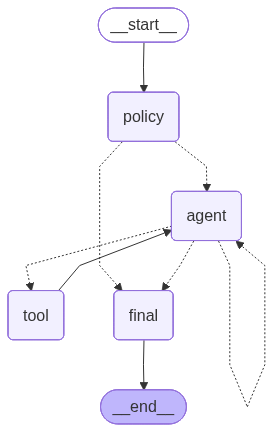

In [37]:
display(Image(agent_app.get_graph().draw_mermaid_png()))    # visualize the graph structure (requires graphviz; can also export to mermaid or other formats if preferred)

# **Scenarios**

In [42]:
class QueryParam(TypedDict):
    patient_id: str
    query: str
    maxSteps: int

def displayStateData(param: QueryParam, out: Dict[str, Any]) -> None:
    printmd("---")
    printmd(f"# <font color='#0E4C92'><B>My Patient Id is: {param['patient_id']}. {param['query']}</B></font>")
    # printmd(f"**Max Steps**: {param['maxSteps']}")
    printmd("## Answer")
    printmd(out["final_answer"])
    printmd("---")
    printmd("## Traceback")
    for i, m in enumerate(out["messages"]):
        printmd(f"### {i}. {type(m).__name__}")
        # Print tool call info if present
        if hasattr(m, "tool_calls") and m.tool_calls:
            printmd("#### Tool calls:")
            printmd(f"> {m.tool_calls}")
        content = getattr(m, "content", "")
        if isinstance(content, str):
            printmd("#### Content:")
            printmd(f"> {content[:8000] if len(content) > 0 else '-- No Content --'}")  # adjust length if needed

In [43]:
queryParams: List[QueryParam] = [{
    "patient_id": "P001",
    "query": "What does my Hemoglobin A1C result mean?",
    "maxSteps": 2
}, {
    "patient_id": "P002",
    "query": "Can you explain my recent high blood pressure readings?",
    "maxSteps": 3
}, {
    "patient_id": "P003",
    "query": "What medications am I currently taking and why?",
    "maxSteps": 2
}, {
    "patient_id": "P004",
    "query": "Do I have any allergies I should be aware of?",
    "maxSteps": 2
}, {
    "patient_id": "P005",
    "query": "Can you summarize my recent hospital visit and labs?",
    "maxSteps": 4
}, {
    "patient_id": "P006",
    "query": "What does my recent cholesterol panel indicate about my heart health?",
    "maxSteps": 3
}, {
    "patient_id": "P007",
    "query": "Are there any concerning trends in my recent lab results?",
    "maxSteps": 3
}]

for param in queryParams:
    pid = param["patient_id"]
    query = param["query"]
    maxSteps = param["maxSteps"]
    state = init_state(pid, query, max_steps=maxSteps)    # complete the code to define the number of iterations for the ReAct loop
    out = agent_app.invoke(state)
    displayStateData(param, out)

---

# <font color='#0E4C92'><B>My Patient Id is: P001. What does my Hemoglobin A1C result mean?</B></font>

## Answer

I may not all the information yet to answer confidently.I can explain what your records show or share general information. For medical advice (especially medication changes) or urgent concerns, please contact your clinician.

---

...

#### Content:

> -- No Content --

### 7. ToolMessage

#### Content:

> {"test_name_normalized": "Sodium", "plain_language_summary": "Sodium is a common lab test. Results are interpreted in the context of your symptoms and other labs.", "why_it_matters": "It can help monitor overall health and specific organs depending on the test.", "common_reasons_high": "May reflect many causes including dehydration, diet, medications, or organ function changes.", "common_reasons_low": "May reflect nutritional status, hydration, or other conditions depending on the test.", "when_to_contact_clinician": "Contact your clinician if you have concerning symptoms or repeated abnormal results.", "citation_url": "https://medlineplus.gov/lab-tests/", "source_id": "S01"}

# **Conclusions and Business Recommendations**

## Conclusions

* A
* B
* C


## Business Recommendations

* A
* B
* C
